## Laptop Price Prediction - Regression ML Project

Explore and clean the data

Engineer useful features

Encode categorical variables and scale numeric ones

Train and tune 8 regression models

Compare them and save the best one for deployment (see app.py)

## 1. Import Libraries

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import StandardScaler,OneHotEncoder,PolynomialFeatures
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

pd.set_option("display.max_columns", None)

## 2. Load Dataset

In [59]:
df = pd.read_csv('data.csv')
df.head()

,Unnamed: 0.1,Unnamed: 0,brand,name,price,spec_rating,processor,CPU,Ram,Ram_type,ROM,ROM_type,GPU,display_size,resolution_width,resolution_height,OS,warranty
0,0,0,HP,Victus 15-fb0157AX Gaming Laptop,49900,73.000000,5th Gen AMD Ryzen 5 5600H,"Hexa Core, 12 Threads",8GB,DDR4,512GB,SSD,4GB AMD Radeon RX 6500M,15.6,1920.0,1080.0,Windows 11 OS,1
1,1,1,HP,15s-fq5007TU Laptop,39900,60.000000,12th Gen Intel Core i3 1215U,"Hexa Core (2P + 4E), 8 Threads",8GB,DDR4,512GB,SSD,Intel UHD Graphics,15.6,1920.0,1080.0,Windows 11 OS,1
2,2,2,Acer,One 14 Z8-415 Laptop,26990,69.323529,11th Gen Intel Core i3 1115G4,"Dual Core, 4 Threads",8GB,DDR4,512GB,SSD,Intel Iris Xe Graphics,14.0,1920.0,1080.0,Windows 11 OS,1
3,3,3,Lenovo,Yoga Slim 6 14IAP8 82WU0095IN Laptop,59729,66.000000,12th Gen Intel Core i5 1240P,"12 Cores (4P + 8E), 16 Threads",16GB,LPDDR5,512GB,SSD,Intel Integrated Iris Xe,14.0,2240.0,1400.0,Windows 11 OS,1
4,4,4,Apple,MacBook Air 2020 MGND3HN Laptop,69990,69.323529,Apple M1,Octa Core (4P + 4E),8GB,DDR4,256GB,SSD,Apple M1 Integrated Graphics,13.3,2560.0,1600.0,Mac OS,1


In [60]:
print("shape:", df.shape)

shape: (893, 18)


In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 893 entries, 0 to 892
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0.1       893 non-null    int64  
 1   Unnamed: 0         893 non-null    int64  
 2   brand              893 non-null    object 
 3   name               893 non-null    object 
 4   price              893 non-null    int64  
 5   spec_rating        893 non-null    float64
 6   processor          893 non-null    object 
 7   CPU                893 non-null    object 
 8   Ram                893 non-null    object 
 9   Ram_type           893 non-null    object 
 10  ROM                893 non-null    object 
 11  ROM_type           893 non-null    object 
 12  GPU                893 non-null    object 
 13  display_size       893 non-null    float64
 14  resolution_width   893 non-null    float64
 15  resolution_height  893 non-null    float64
 16  OS                 893 non

## 3. Exploratory Data Analysis (EDA)

We look at the data from several angles before touching it, so we understand what we are working with.

### 3.1 Dataset overview

In [62]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0.1,893.0,NaN,NaN,NaN,467.135498,270.209769,0.0,235.0,467.0,702.0,930.0
Unnamed: 0,893.0,NaN,NaN,NaN,521.382979,299.916605,0.0,265.0,531.0,784.0,1019.0
brand,893,30,HP,186,NaN,NaN,NaN,NaN,NaN,NaN,NaN
name,893,815,Inspiron 3525 Laptop,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,893.0,NaN,NaN,NaN,79907.409854,60880.043823,9999.0,44500.0,61990.0,90990.0,450039.0
spec_rating,893.0,NaN,NaN,NaN,69.379026,5.541555,60.0,66.0,69.323529,71.0,89.0
processor,893,184,12th Gen Intel Core i5 1235U,49,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CPU,893,29,"Quad Core, 8 Threads",130,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ram,893,7,16GB,456,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ram_type,893,12,DDR4,499,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 3.2 Missing values

In [63]:
df.isna().sum()

Unnamed: 0.1         0
Unnamed: 0           0
brand                0
name                 0
price                0
spec_rating          0
processor            0
CPU                  0
Ram                  0
Ram_type             0
ROM                  0
ROM_type             0
GPU                  0
display_size         0
resolution_width     0
resolution_height    0
OS                   0
warranty             0
dtype: int64

### 3.3 Duplicate rows

In [64]:
print("Number of Duplicate rows:",df.duplicated().sum())

Number of Duplicate rows: 0


### 3.4 Statistical summary (numeric columns)

In [65]:
num_preview_cols = ["price","spec_rating","display_size","resolution_width","resolution_height","warranty"]
df[num_preview_cols].describe()

,price,spec_rating,display_size,resolution_width,resolution_height,warranty
count,893.000000,893.000000,893.000000,893.000000,893.000000,893.000000
mean,79907.409854,69.379026,15.173751,2035.393057,1218.324748,1.079507
std,60880.043823,5.541555,0.939095,426.076009,326.756883,0.326956
min,9999.000000,60.000000,11.600000,1080.000000,768.000000,0.000000
25%,44500.000000,66.000000,14.000000,1920.000000,1080.000000,1.000000
50%,61990.000000,69.323529,15.600000,1920.000000,1080.000000,1.000000
75%,90990.000000,71.000000,15.600000,1920.000000,1200.000000,1.000000
max,450039.000000,89.000000,18.000000,3840.000000,3456.000000,3.000000


### 3.5 Target distribution (price)

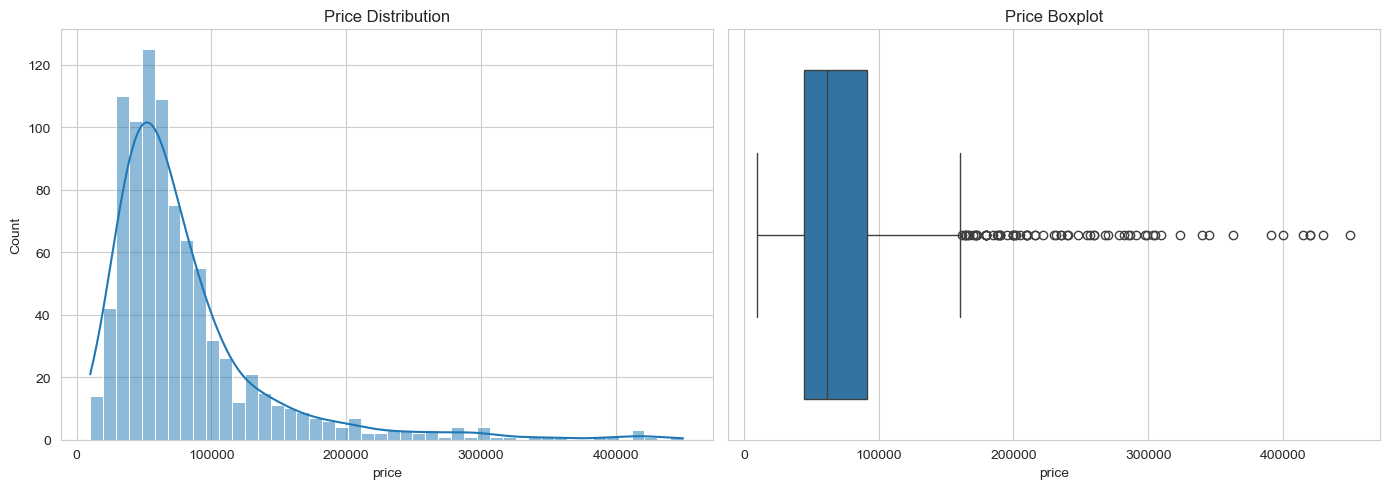

In [66]:
fig, axes = plt.subplots(1,2, figsize=(14,5))
sns.histplot(df['price'], kde=True, ax=axes[0])
axes[0].set_title("Price Distribution")
sns.boxplot(x=df['price'], ax=axes[1])
axes[1].set_title("Price Boxplot")
plt.tight_layout()
plt.show()

### 3.6 Histograms of numeric features

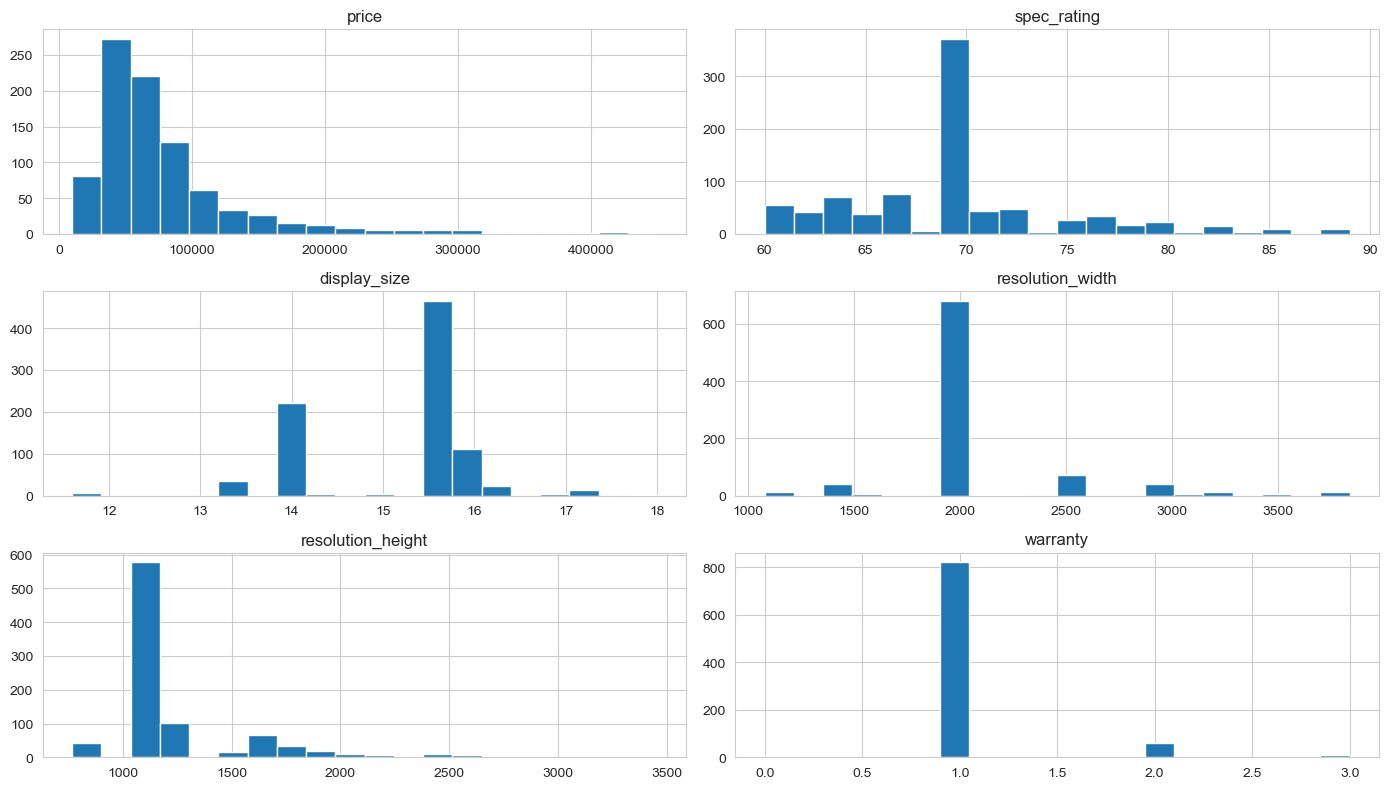

In [67]:
df[num_preview_cols].hist(bins=20, figsize=(14,8))
plt.tight_layout()
plt.show()

### 3.7 Boxplots of numeric features

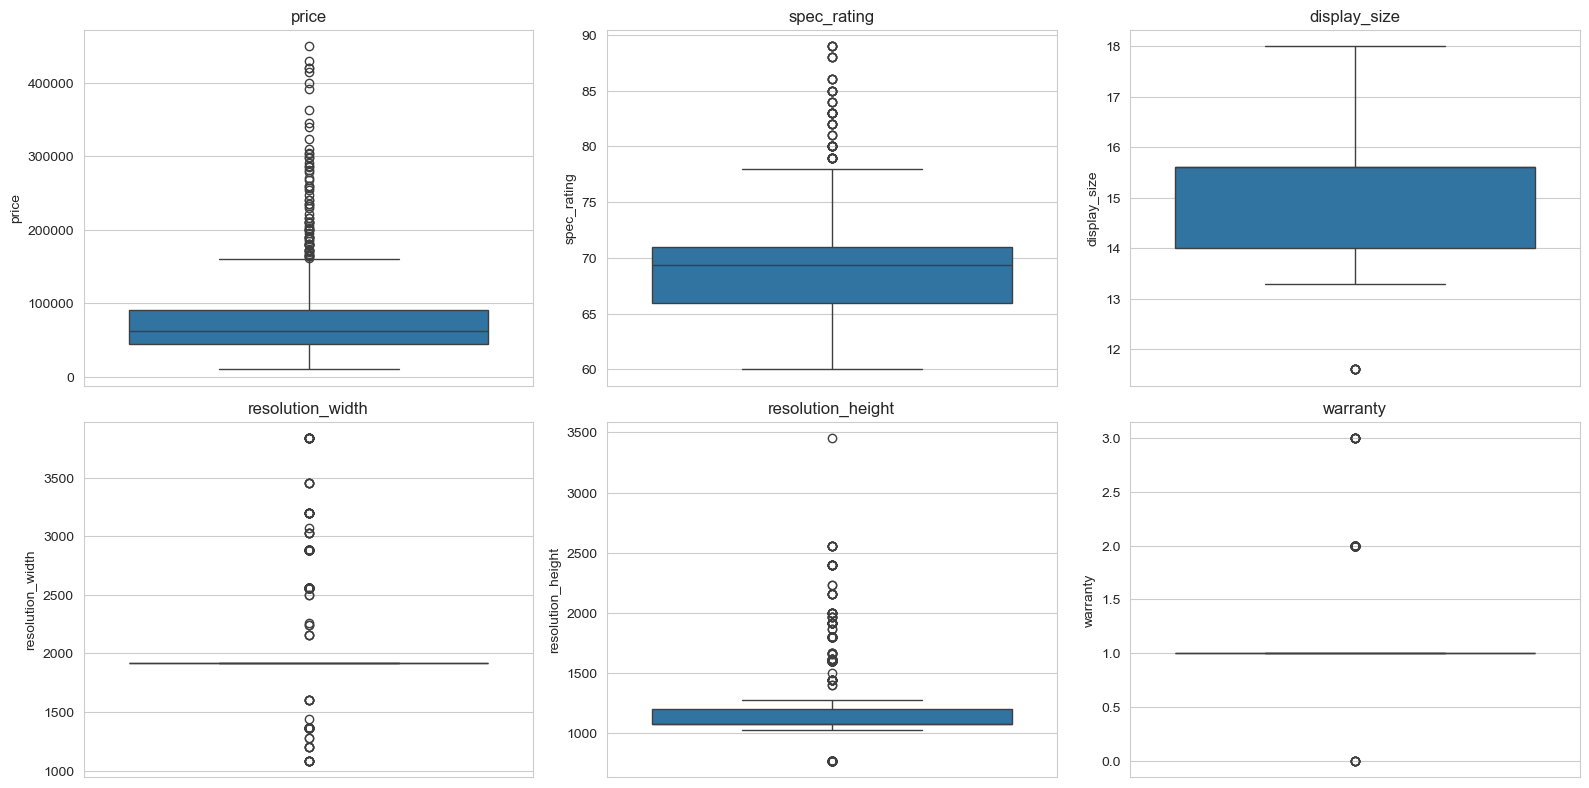

In [68]:
fig, axes = plt.subplots(2,3, figsize=(16,8))
for ax, col in zip(axes.flatten(), num_preview_cols):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

### 3.8 Pairplot (selected numerical features)

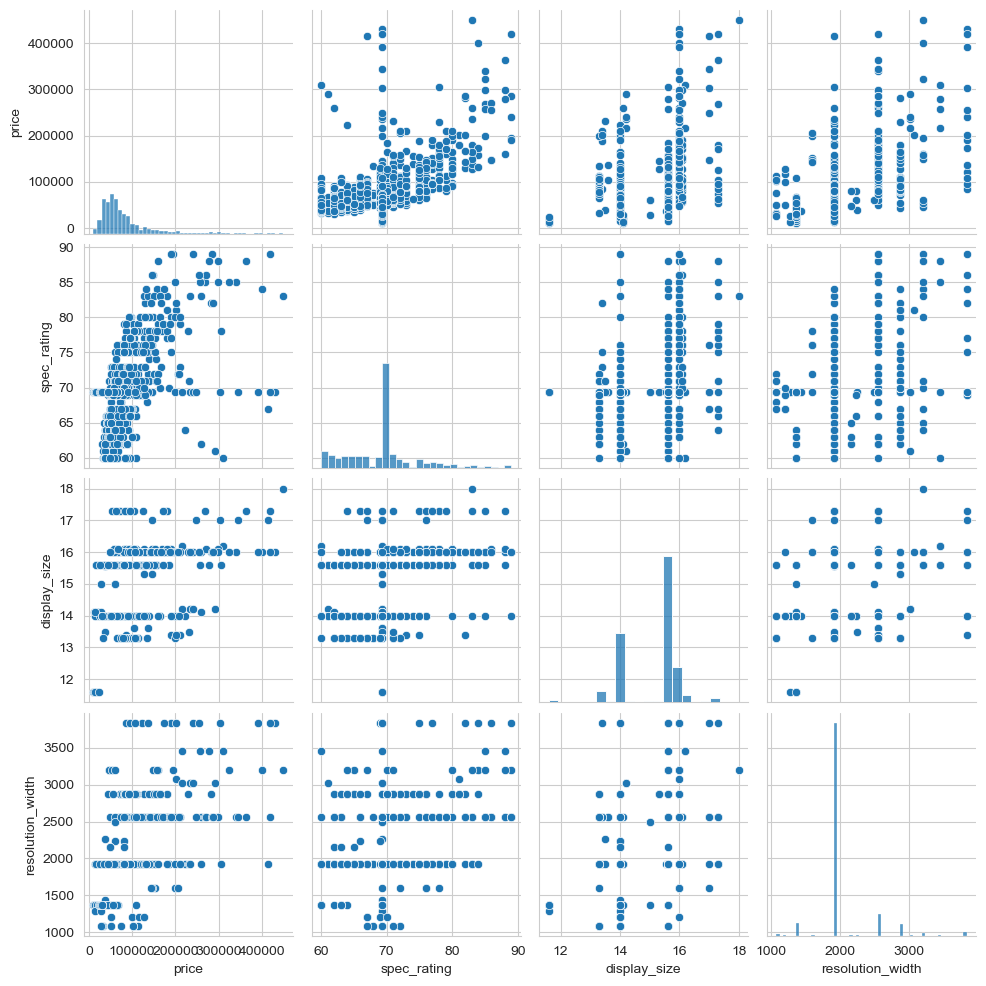

In [69]:
sns.pairplot(df[["price", "spec_rating", "display_size", "resolution_width"]])
plt.show()

### 3.9 Categorical count plots

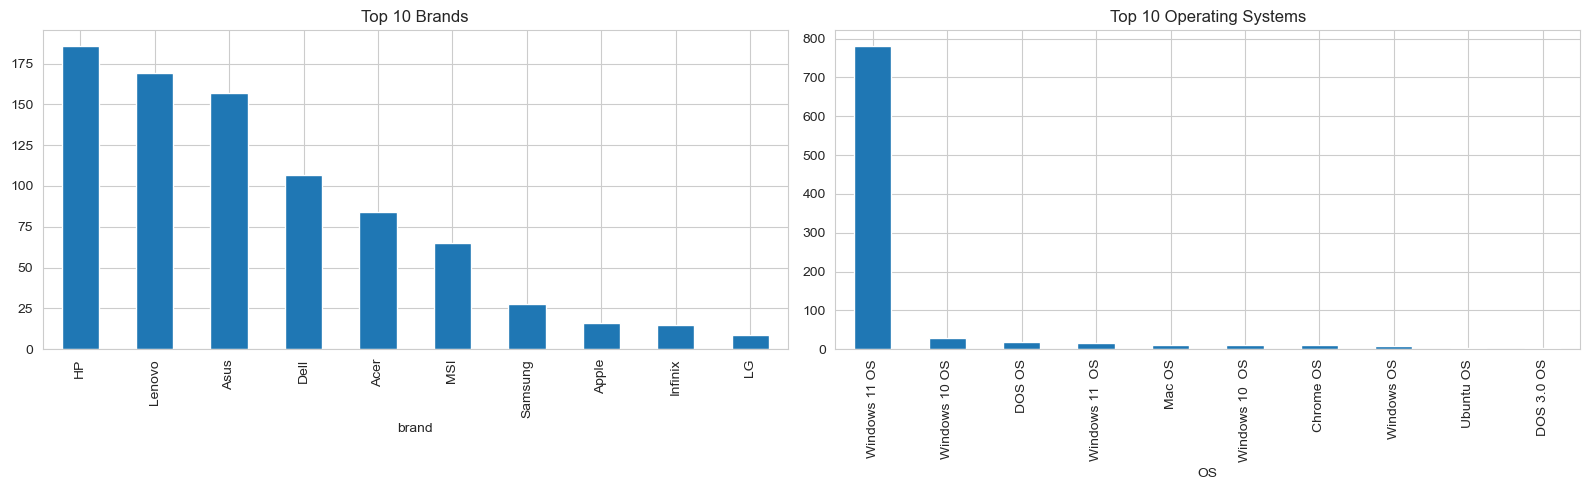

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
df["brand"].value_counts().head(10).plot(kind="bar", ax=axes[0], title="Top 10 Brands")
df["OS"].value_counts().head(10).plot(kind="bar", ax=axes[1], title="Top 10 Operating Systems")
plt.tight_layout()
plt.show()

### 3.10 Price vs Brand

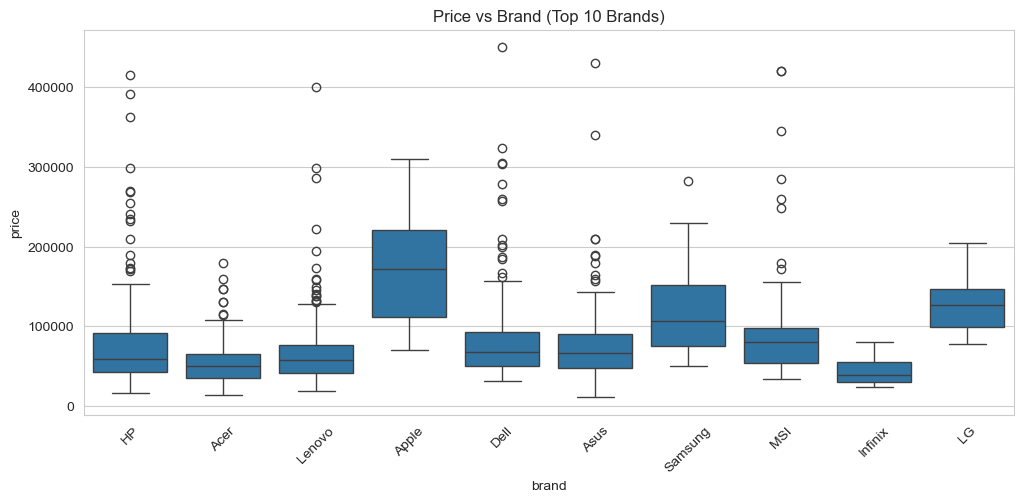

In [71]:
top_brands = df["brand"].value_counts().head(10).index
plt.figure(figsize=(12, 5))
sns.boxplot(data=df[df["brand"].isin(top_brands)], x="brand", y="price")
plt.xticks(rotation=45)
plt.title("Price vs Brand (Top 10 Brands)")
plt.show()

### 3.11 Price vs RAM

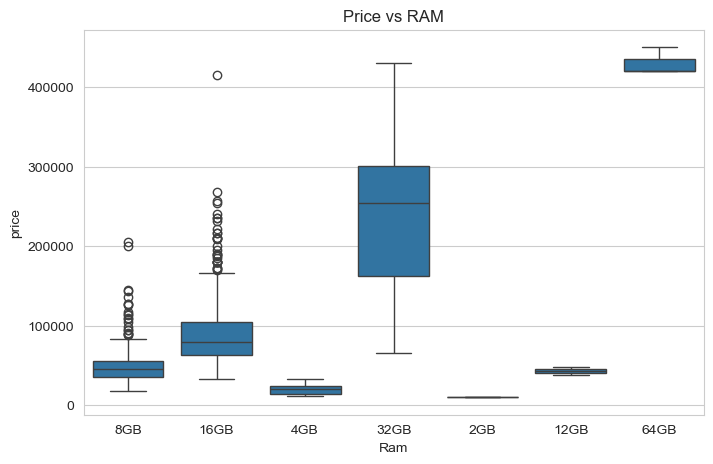

In [72]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Ram", y="price")
plt.title("Price vs RAM")
plt.show()

### 3.12 Price vs Processor (brand-level, since exact processor has too many unique values)

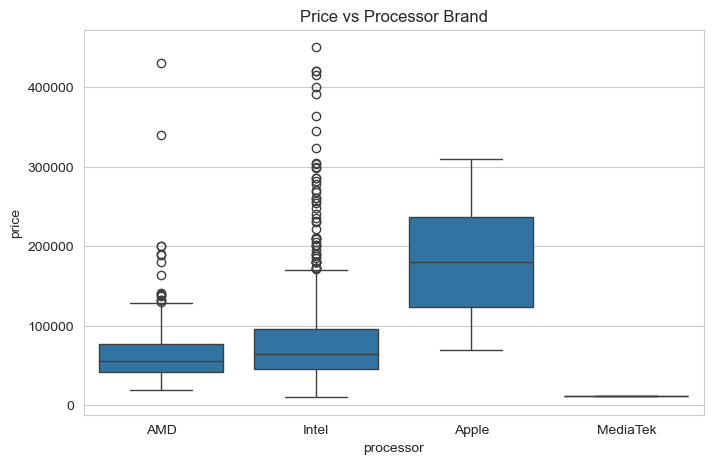

In [73]:
def quick_processor_brand(x):
    x = str(x).lower()
    if "intel" in x:
        return "Intel"
    if "amd" in x or "ryzen" in x:
        return "AMD"
    if "apple" in x or "m1" in x or "m2" in x or "m3" in x:
        return "Apple"
    if "mediatek" in x:
        return "MediaTek"
    if "qualcomm" in x or "snapdragon" in x:
        return "Qualcomm"
    return "Other"

plt.figure(figsize=(8, 5))
sns.boxplot(x=df["processor"].apply(quick_processor_brand), y=df["price"])
plt.title("Price vs Processor Brand")
plt.show()


### 3.13 Price vs OS

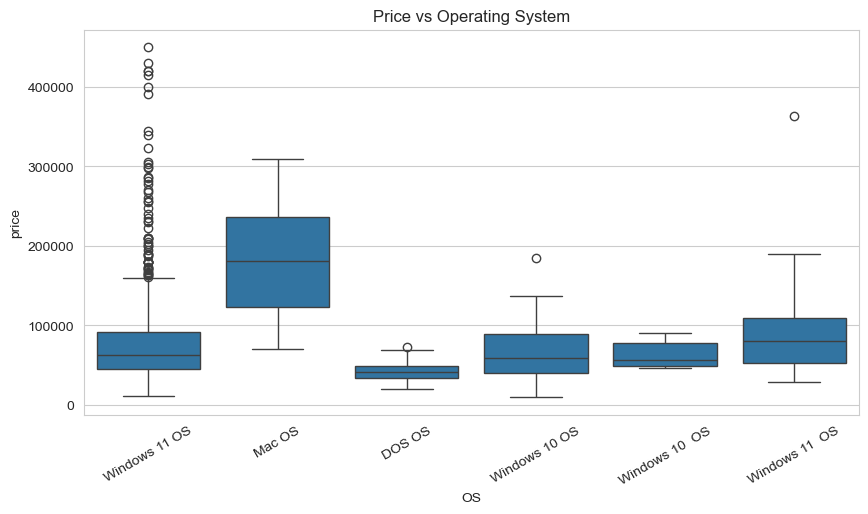

In [74]:
top_os = df["OS"].value_counts().head(6).index
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[df["OS"].isin(top_os)], x="OS", y="price")
plt.xticks(rotation=30)
plt.title("Price vs Operating System")
plt.show()

### 3.14 Correlation heatmap (numeric features)

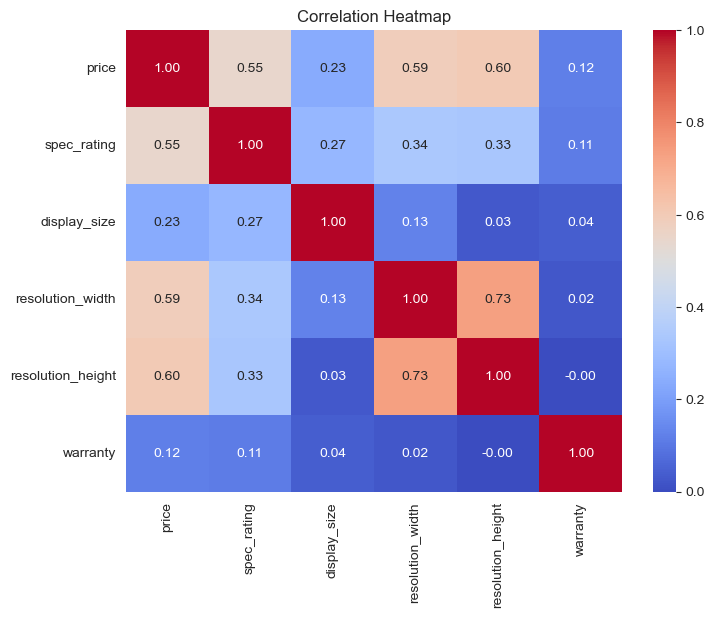

In [75]:
plt.figure(figsize=(8,6))
sns.heatmap(df[num_preview_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

## 4. Data Cleaning

We drop the two unnamed index columns (leftovers from saving the CSV), remove duplicate rows, and check for missing values.

In [76]:
df_clean = df.drop(columns=["Unnamed: 0","Unnamed: 0.1"])
df_clean = df_clean.drop_duplicates()
df_clean = df_clean.dropna()

# The 'name' column is almost unique per row (it's the laptop model name),
# so it doesn't help a regression model generalize — we drop it too.
df_clean = df_clean.drop(columns=["name"])

print("Shape after cleaning:", df_clean.shape)
df_clean.head()

Shape after cleaning: (893, 15)


,brand,price,spec_rating,processor,CPU,Ram,Ram_type,ROM,ROM_type,GPU,display_size,resolution_width,resolution_height,OS,warranty
0,HP,49900,73.000000,5th Gen AMD Ryzen 5 5600H,"Hexa Core, 12 Threads",8GB,DDR4,512GB,SSD,4GB AMD Radeon RX 6500M,15.6,1920.0,1080.0,Windows 11 OS,1
1,HP,39900,60.000000,12th Gen Intel Core i3 1215U,"Hexa Core (2P + 4E), 8 Threads",8GB,DDR4,512GB,SSD,Intel UHD Graphics,15.6,1920.0,1080.0,Windows 11 OS,1
2,Acer,26990,69.323529,11th Gen Intel Core i3 1115G4,"Dual Core, 4 Threads",8GB,DDR4,512GB,SSD,Intel Iris Xe Graphics,14.0,1920.0,1080.0,Windows 11 OS,1
3,Lenovo,59729,66.000000,12th Gen Intel Core i5 1240P,"12 Cores (4P + 8E), 16 Threads",16GB,LPDDR5,512GB,SSD,Intel Integrated Iris Xe,14.0,2240.0,1400.0,Windows 11 OS,1
4,Apple,69990,69.323529,Apple M1,Octa Core (4P + 4E),8GB,DDR4,256GB,SSD,Apple M1 Integrated Graphics,13.3,2560.0,1600.0,Mac OS,1


## 5. Feature Engineering

We turn text values like "8GB" into numbers, and create a few new features that are more informative for a model than the raw resolution/display size.

### 5.1 RAM and Storage (ROM) → numbers

In [77]:
df_clean["Ram"] = df_clean["Ram"].str.replace("GB","", regex=False).astype(int)

def rom_to_gb(value):
    value = str(value)
    if "TB" in value:
        return int(value.replace("TB",""))*1024
    return int(value.replace("GB",""))

df_clean["ROM"] = df_clean["ROM"].apply(rom_to_gb)

df_clean[["Ram","ROM"]].head()

,Ram,ROM
0,8,512
1,8,512
2,8,512
3,16,512
4,8,256


### 5.2 Extract processor brand and GPU brand
The raw processor and GPU columns have 180+ and 130+ unique values, which is far too many for one-hot encoding to handle well on a dataset this size. Instead, we extract the brand (Intel/AMD/Apple/...), which captures most of the price signal with far fewer categories.

In [78]:
def get_processor_brand(text):
    text = str(text).lower()
    if "intel" in text:
        return "Intel"
    if "amd" in text or "ryzen" in text:
        return "AMD"
    if "apple" in text or "m1" in text or "m2" in text or "m3" in text:
        return "Apple"
    if "mediatek" in text:
        return "MediaTake"
    if "qualcomm" in text or "snapdragon" in text:
        return "Qualcomm"
    return "Other"

def get_gpu_brand(text):
    text = str(text).lower()
    if "nvidia" in text or "geforce" in text or "rtx" in text or "gtx" in text:
        return "NVIDIA"
    if "amd" in text or "radeon" in text:
        return "AMD"
    if "intel" in text:
        return "Intel"
    if "apple" in text:
        return "Apple"
    return "Other"


df_clean["processor_brand"] = df_clean["processor"].apply(get_processor_brand)
df_clean["GPU_brand"] = df_clean["GPU"].apply(get_gpu_brand)

df_clean[["processor_brand", "GPU_brand"]].value_counts().head(10)

processor_brand  GPU_brand
Intel            Intel        397
                 NVIDIA       214
AMD              AMD          172
                 NVIDIA        92
Apple            Other         10
                 Apple          2
Intel            AMD            2
                 Other          2
AMD              Intel          1
MediaTake        Other          1
Name: count, dtype: int64

### 5.3 Resolution-based features

In [79]:
df_clean["Total_pixels"] = df_clean["resolution_width"]*df_clean["resolution_height"]

# Pixels-per-inch style density: diagonal resolution divided by screen size
df_clean["PPI"] = (np.sqrt(df_clean["resolution_width"] ** 2+ df_clean["resolution_height"] ** 2) / df_clean["display_size"])

# Approximate display area (proportional to display_size^2)
df_clean["Display_Area"] = df_clean["display_size"] ** 2

df_clean[["Total_pixels","PPI","Display_Area"]].describe()

,Total_pixels,PPI,Display_Area
count,8.930000e+02,893.000000,893.000000
mean,2.581505e+06,157.262487,231.123643
std,1.340740e+06,33.949659,27.814309
min,1.049088e+06,100.454670,134.560000
25%,2.073600e+06,141.211998,196.000000
50%,2.073600e+06,141.211998,243.360000
75%,2.304000e+06,161.725391,243.360000
max,9.216000e+06,337.933652,324.000000


### 5.4 Drop the raw high-cardinality text columns we've replaced

In [80]:
df_model = df_clean.drop(columns=["processor","CPU","GPU"])
df_model.head()

,brand,price,spec_rating,Ram,Ram_type,ROM,ROM_type,display_size,resolution_width,resolution_height,OS,warranty,processor_brand,GPU_brand,Total_pixels,PPI,Display_Area
0,HP,49900,73.000000,8,DDR4,512,SSD,15.6,1920.0,1080.0,Windows 11 OS,1,AMD,AMD,2073600.0,141.211998,243.36
1,HP,39900,60.000000,8,DDR4,512,SSD,15.6,1920.0,1080.0,Windows 11 OS,1,Intel,Intel,2073600.0,141.211998,243.36
2,Acer,26990,69.323529,8,DDR4,512,SSD,14.0,1920.0,1080.0,Windows 11 OS,1,Intel,Intel,2073600.0,157.350512,196.00
3,Lenovo,59729,66.000000,16,LPDDR5,512,SSD,14.0,2240.0,1400.0,Windows 11 OS,1,Intel,Intel,3136000.0,188.679623,196.00
4,Apple,69990,69.323529,8,DDR4,256,SSD,13.3,2560.0,1600.0,Mac OS,1,Apple,Apple,4096000.0,226.983005,176.89


### 5.5 Define our final feature groups

In [81]:
cat_cols = ["brand","Ram_type","ROM_type","OS","processor_brand","GPU_brand"]
num_cols = ["spec_rating","Ram","ROM","display_size","resolution_width","resolution_height","warranty","Total_pixels","PPI","Display_Area"]

print("Categorical columns:", cat_cols)
print("Numerical columns:", num_cols)

Categorical columns: ['brand', 'Ram_type', 'ROM_type', 'OS', 'processor_brand', 'GPU_brand']
Numerical columns: ['spec_rating', 'Ram', 'ROM', 'display_size', 'resolution_width', 'resolution_height', 'warranty', 'Total_pixels', 'PPI', 'Display_Area']


## 6. Encoding Categorical Variables
We use One-Hot Encoding (not Label Encoding) because these are nominal categories - there is no natural order between "HP" and "Dell", for example. sklearn's OneHotEncoder is used instead of pd.get_dummies because it can be saved and reused later inside the Streamlit app.

In [82]:
X = df_model[cat_cols + num_cols]
y = df_model["price"]

X.head()

,brand,Ram_type,ROM_type,OS,processor_brand,GPU_brand,spec_rating,Ram,ROM,display_size,resolution_width,resolution_height,warranty,Total_pixels,PPI,Display_Area
0,HP,DDR4,SSD,Windows 11 OS,AMD,AMD,73.000000,8,512,15.6,1920.0,1080.0,1,2073600.0,141.211998,243.36
1,HP,DDR4,SSD,Windows 11 OS,Intel,Intel,60.000000,8,512,15.6,1920.0,1080.0,1,2073600.0,141.211998,243.36
2,Acer,DDR4,SSD,Windows 11 OS,Intel,Intel,69.323529,8,512,14.0,1920.0,1080.0,1,2073600.0,157.350512,196.00
3,Lenovo,LPDDR5,SSD,Windows 11 OS,Intel,Intel,66.000000,16,512,14.0,2240.0,1400.0,1,3136000.0,188.679623,196.00
4,Apple,DDR4,SSD,Mac OS,Apple,Apple,69.323529,8,256,13.3,2560.0,1600.0,1,4096000.0,226.983005,176.89


In [83]:
y

0       49900
1       39900
2       26990
3       59729
4       69990
        ...  
888     44990
889    110000
890    189990
891    129990
892    131990
Name: price, Length: 893, dtype: int64

## 7. Feature Scaling
We scale numeric columns with StandardScaler. This matters most for Linear/Ridge/Lasso/ElasticNet, KNN, and SVR, which are all sensitive to the scale of the input features. (The encoder and scaler are fit only on the training set below, to avoid leaking test-set information.)

### 8. Train-Test Split (80% train / 20% test)

In [84]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train_raw.shape)
print("Test shape:", X_test_raw.shape)

Train shape: (714, 16)
Test shape: (179, 16)


Now fit the encoder and scaler on the training data only, then transform both sets:

In [85]:
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoder.fit(X_train_raw[cat_cols])

scaler = StandardScaler()
scaler.fit(X_train_raw[num_cols])

def transform_features(X_part):
    cat_encoded = encoder.transform(X_part[cat_cols])
    num_scaled = scaler.transform(X_part[num_cols])
    return np.hstack([num_scaled, cat_encoded])

X_train = transform_features(X_train_raw)
X_test = transform_features(X_test_raw)

# Human-readable names for every column in X_train / X_test, in the same order 
feature_names = num_cols + list(encoder.get_feature_names_out(cat_cols))

print("Final training matrix shape:", X_train.shape)
print("Number of features:", len(feature_names))

Final training matrix shape: (714, 74)
Number of features: 74


### 9. Train Eight Regression Models
We start with sensible default settings for each model. Polynomial Regression is trained on the numeric features only (rather than all ~74 encoded features) — expanding every one-hot column to degree 2 would create far too many features for 700 training rows and the model would badly overfit.

In [86]:
# Extra matrices for Polynomial Regression: numeric features only
X_train_num = scaler.transform(X_train_raw[num_cols])
X_test_num = scaler.transform(X_test_raw[num_cols])

Poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = Poly.fit_transform(X_train_num)
X_test_poly = Poly.transform(X_test_num)

print("Polynomial feature matrix shape:", X_train_poly.shape)

Polynomial feature matrix shape: (714, 65)


In [87]:
models = {
    "Linear Regression": (LinearRegression(), X_train, X_test),
    "Ridge Regression": (Ridge(alpha=1.0), X_train, X_test),
    "Lasso Regression": (Lasso(alpha=1.0, max_iter=5000), X_train, X_test),
    "ElasticNet Regression": (ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=5000), X_train,X_test),
    "Polynomial Regression": (LinearRegression(), X_train_poly, X_test_poly),
    "KNeighbors Regressor": (KNeighborsRegressor(), X_train,X_test),
    "Support Vector Regressor": (SVR(), X_train, X_test),
    "Decision Tree Regressor": (DecisionTreeRegressor(random_state=42), X_train, X_test),
}

trained_models = {}
for name, (model, X_tr, X_te) in models.items():
    model.fit(X_tr, y_train)
    trained_models[name] = model

print("All 8 models trained.")

All 8 models trained.


d:\Anocanda\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.262e+09, tolerance: 2.691e+08
  model = cd_fast.enet_coordinate_descent(


### 10. Hyperparameter Tuning
We use GridSearchCV (5-fold cross-validation) to search a small, sensible grid of hyperparameters for each tunable model. Grids are kept small so this runs quickly — feel free to widen them once the pipeline works.

In [88]:
param_grids = {
    "Ridge Regression": {
        "alpha": [0.1, 1.0, 10.0, 50.0, 100.0]
    },
    "Lasso Regression": {
        "alpha": [0.1, 1.0, 10.0, 50.0, 100.0]
    },
    "ElasticNet Regression": {
        "alpha": [0.1, 1.0, 10.0],
        "l1_ratio": [0.2, 0.5, 0.8]
    },
    "KNeighbors Regressor": {
        "n_neighbors": [3, 5, 7, 9, 11],
        "weights": ["uniform", "distance"],
        "metric": ["euclidean", "manhattan"]
    },
    "Support Vector Regressor": {
        "kernel": ["rbf", "linear"],
        "C": [1, 10, 100],
        "gamma": ["scale", "auto"],
        "epsilon": [0.1, 1, 10]
    },
    "Decision Tree Regressor": {
        "max_depth": [3, 5, 8, 12, None],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4]
    },
}


base_estimators = {
    "Ridge Regression": Ridge(),
    "Lasso Regression": Lasso(max_iter=5000),
    "ElasticNet Regression": ElasticNet(max_iter=5000),
    "KNeighbors Regressor": KNeighborsRegressor(),
    "Support Vector Regressor": SVR(),
    "Decision Tree Regressor": DecisionTreeRegressor(random_state=42),
}

for name, grid in param_grids.items():
    search = GridSearchCV(base_estimators[name], grid, cv=5, scoring="r2", n_jobs=-1)
    search.fit(X_train, y_train)
    trained_models[name] = search.best_estimator_
    print(f"{name}: best params = {search.best_params_}")

Ridge Regression: best params = {'alpha': 1.0}
Lasso Regression: best params = {'alpha': 50.0}
ElasticNet Regression: best params = {'alpha': 0.1, 'l1_ratio': 0.8}
KNeighbors Regressor: best params = {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'}
Support Vector Regressor: best params = {'C': 100, 'epsilon': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Decision Tree Regressor: best params = {'max_depth': 8, 'min_samples_leaf': 4, 'min_samples_split': 2}


Polynomial Regression: search the best degree separately, since it needs its own feature matrix.

In [89]:
best_poly_score = -np.inf
best_degree = 2
best_poly_model = None
best_poly_test = None

for degree in [1, 2, 3]:
    poly_d = PolynomialFeatures(degree=degree, include_bias=False)
    Xtr_d = poly_d.fit_transform(X_train_num)
    Xte_d = poly_d.transform(X_test_num)
    lr = LinearRegression().fit(Xtr_d, y_train)
    score = r2_score(y_test, lr.predict(Xte_d))
    print(f"degree={degree}: R2={score:.3f}")
    if score > best_poly_score:
        best_poly_score = score
        best_degree = degree
        best_poly_model = lr
        best_poly_test = Xte_d

trained_models["Polynomial Regression"] = best_poly_model
print("Best polynomial degree:", best_degree)

degree=1: R2=0.778
degree=2: R2=0.660
degree=3: R2=-436856215.250
Best polynomial degree: 1


### 11. Model Evaluation
We compute MAE, MSE, RMSE, R², and Adjusted R² for every tuned model and rank them.

In [90]:
def adjusted_r2(r2, n_samples, n_features):
    return 1 - (1 - r2) * (n_samples - 1) / (n_samples - n_features - 1)

eval_inputs = {
    "Linear Regression": X_test,
    "Ridge Regression": X_test,
    "Lasso Regression": X_test,
    "ElasticNet Regression": X_test,
    "Polynomial Regression": best_poly_test,
    "KNeighbors Regressor": X_test,
    "Support Vector Regressor": X_test,
    "Decision Tree Regressor": X_test,
}

results = []
predictions = {}
for name, model in trained_models.items():
    X_te = eval_inputs[name]
    preds = model.predict(X_te)
    predictions[name] = preds

    mae = mean_absolute_error(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, preds)
    adj_r2 = adjusted_r2(r2, X_te.shape[0], X_te.shape[1])

    results.append([name, mae, mse, rmse, r2, adj_r2])

results_df = pd.DataFrame(
    results, columns=["Model", "MAE", "MSE", "RMSE", "R2", "Adjusted_R2"]
).sort_values("R2", ascending=False).reset_index(drop=True)

results_df

,Model,MAE,MSE,RMSE,R2,Adjusted_R2
0,KNeighbors Regressor,14615.879261,5.757087e+08,23993.929680,0.831991,0.712445
1,Ridge Regression,17261.764715,5.846441e+08,24179.414426,0.829383,0.707982
2,Linear Regression,17164.694440,5.909368e+08,24309.191184,0.827547,0.704839
3,Lasso Regression,17364.688149,6.014090e+08,24523.641396,0.824490,0.699609
4,ElasticNet Regression,17515.104670,6.121115e+08,24740.886349,0.821367,0.694263
5,Polynomial Regression,19330.869896,7.596094e+08,27561.012652,0.778323,0.765128
6,Decision Tree Regressor,18270.109202,8.437921e+08,29048.099959,0.753756,0.578543
7,Support Vector Regressor,18106.771652,1.000802e+09,31635.447605,0.707935,0.500120


## 12. Visualizations

### 12.1 Model comparison bar chart (R² and RMSE)

C:\Users\Acer\AppData\Local\Temp\ipykernel_18128\1859914372.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data= results_df, x="R2", y="Model", ax=axes[0], palette="viridis")
C:\Users\Acer\AppData\Local\Temp\ipykernel_18128\1859914372.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="RMSE", y="Model", ax=axes[1], palette="magma")


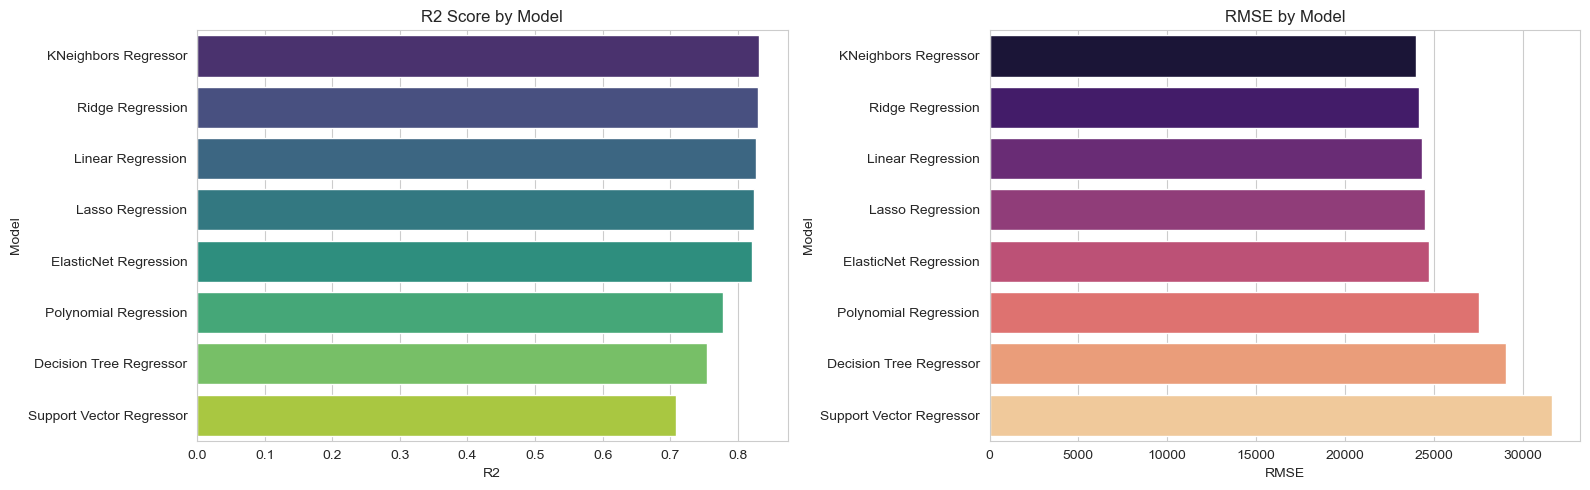

In [91]:
fig, axes = plt.subplots(1, 2, figsize=(16,5))
sns.barplot(data= results_df, x="R2", y="Model", ax=axes[0], palette="viridis")
axes[0].set_title("R2 Score by Model")
sns.barplot(data=results_df, x="RMSE", y="Model", ax=axes[1], palette="magma")
axes[1].set_title("RMSE by Model")
plt.tight_layout()
plt.show()

### 12.2 Actual vs Predicted (best model)

Best model : KNeighbors Regressor


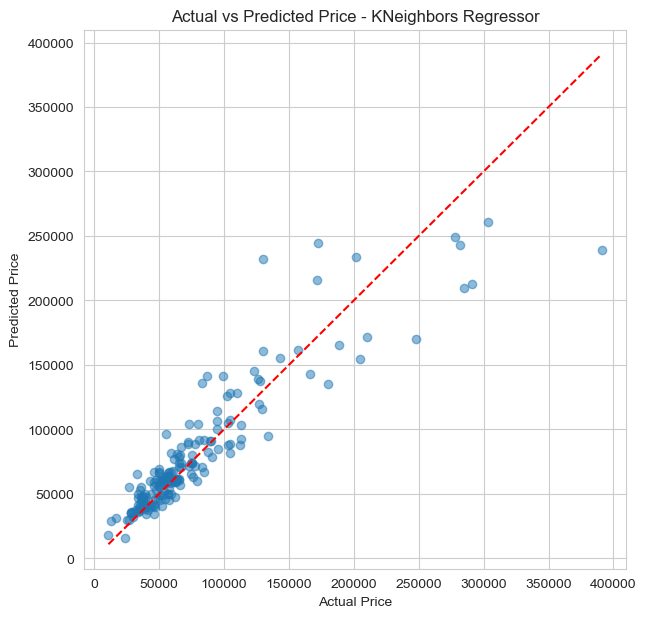

In [92]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]
best_preds = predictions[best_model_name]

print("Best model :", best_model_name)

plt.figure(figsize=(7,7))
plt.scatter(y_test, best_preds, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title(f"Actual vs Predicted Price - {best_model_name}")
plt.show()

### 12.3 Residual plot and residual distribution

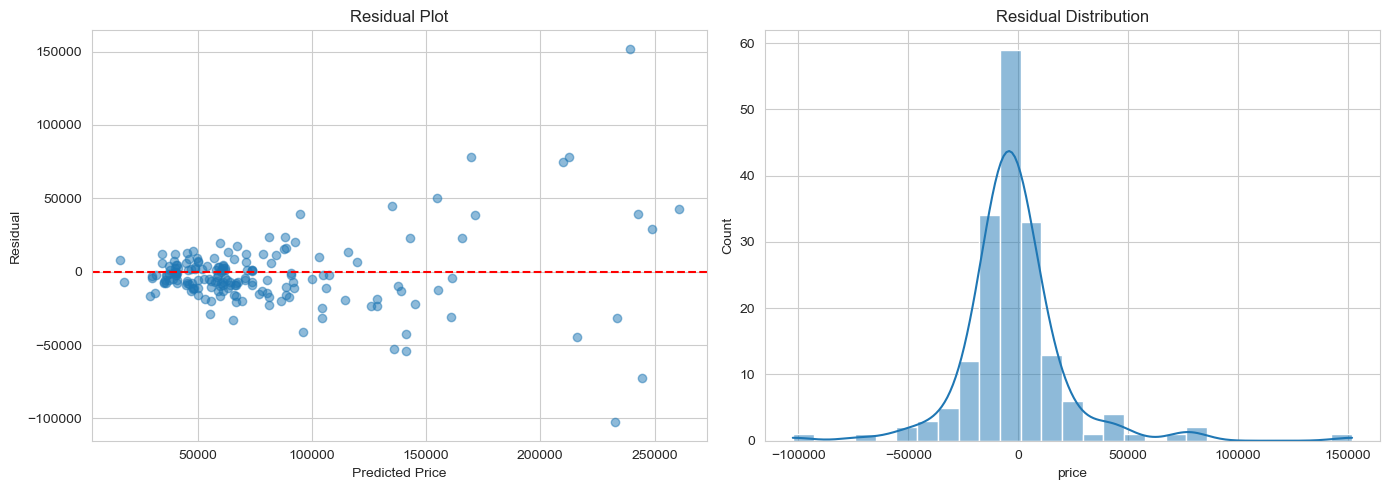

In [93]:
residuals = y_test - best_preds

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(best_preds, residuals, alpha = 0.5)
axes[0].axhline(0, color='r',linestyle="--")
axes[0].set_xlabel("Predicted Price")
axes[0].set_ylabel("Residual")
axes[0].set_title("Residual Plot")

sns.histplot(residuals, kde=True, ax= axes[1])
axes[1].set_title("Residual Distribution")
plt.tight_layout()
plt.show()

### 12.4 Decision Tree feature importance

C:\Users\Acer\AppData\Local\Temp\ipykernel_18128\693680302.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette="crest")


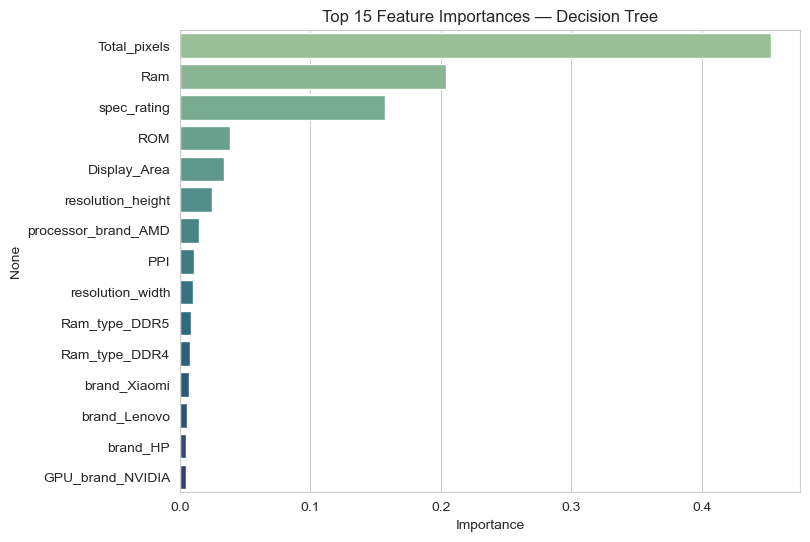

In [94]:
dt_model = trained_models["Decision Tree Regressor"]
importances = pd.Series(dt_model.feature_importances_, index=feature_names)
importances = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index, palette="crest")
plt.title("Top 15 Feature Importances — Decision Tree")
plt.xlabel("Importance")
plt.show()

### 12.5 Coefficient plots (Linear, Ridge, Lasso)

C:\Users\Acer\AppData\Local\Temp\ipykernel_18128\2316847141.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=coefs.values, y=coefs.index, ax=ax, palette="coolwarm")
C:\Users\Acer\AppData\Local\Temp\ipykernel_18128\2316847141.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=coefs.values, y=coefs.index, ax=ax, palette="coolwarm")
C:\Users\Acer\AppData\Local\Temp\ipykernel_18128\2316847141.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=coefs.values, y=coefs.index, ax=ax, palette="coolwarm")


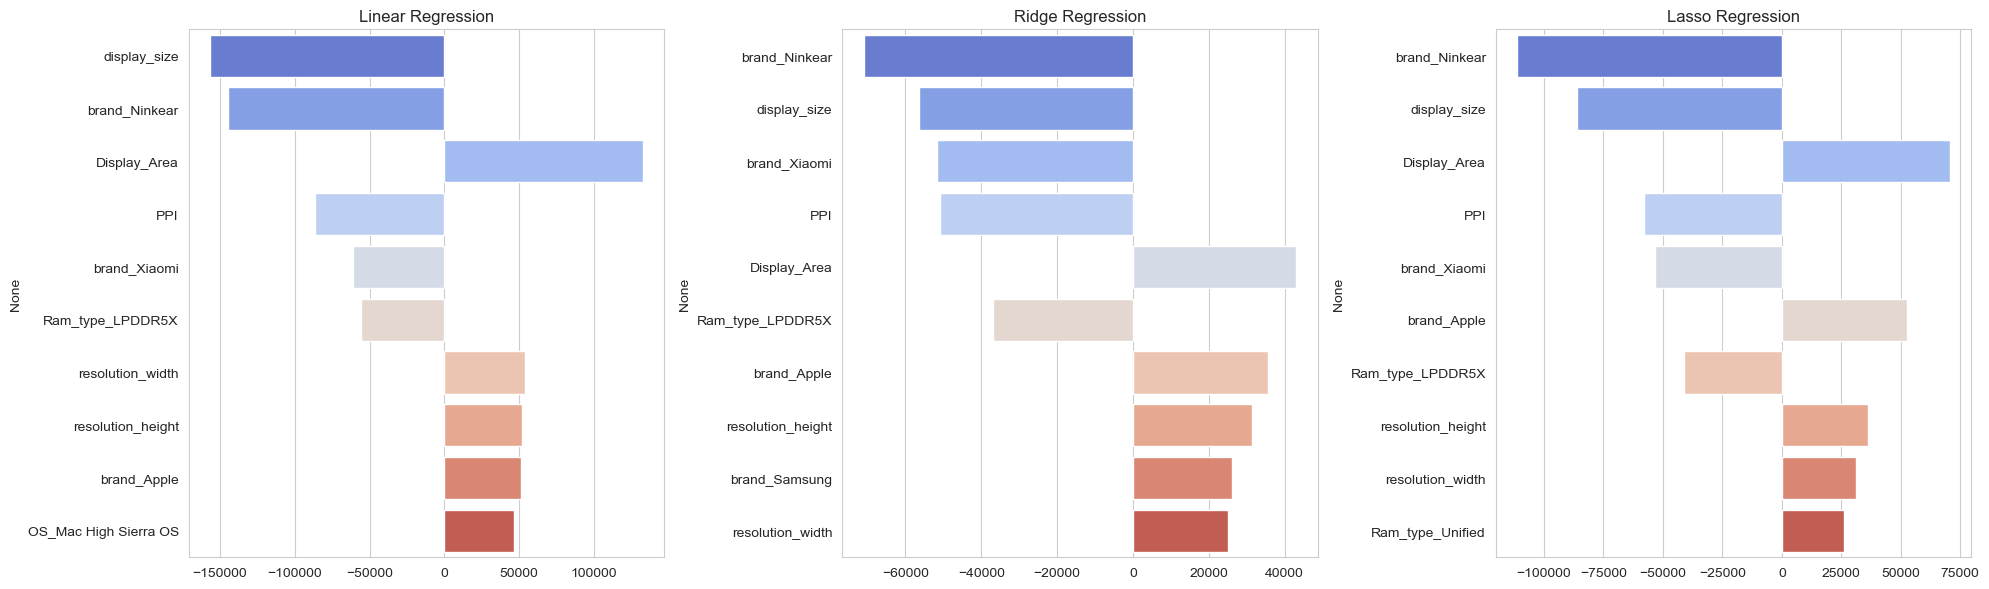

In [95]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, name in zip(axes, ["Linear Regression", "Ridge Regression", "Lasso Regression"]):
    coefs = pd.Series(trained_models[name].coef_, index=feature_names)
    coefs = coefs.reindex(coefs.abs().sort_values(ascending=False).head(10).index)
    sns.barplot(x=coefs.values, y=coefs.index, ax=ax, palette="coolwarm")
    ax.set_title(name)
plt.tight_layout()
plt.show()

## 13. Save the Best Model
We save the winning model plus the scaler and encoder (so the exact same preprocessing can be reproduced in the Streamlit app), along with a small metadata file describing the expected inputs and dropdown options.

In [96]:
joblib.dump(best_model, "best_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(encoder, "encoder.pkl")

# Metadata needed to rebuild the Streamlit UI and preprocessing pipeline
meta = {
    "best_model_name": best_model_name,
    "cat_cols": cat_cols,
    "num_cols": num_cols,
    "feature_names": feature_names,
    "uses_polynomial": best_model_name == "Polynomial Regression",
    "poly_degree": best_degree if best_model_name == "Polynomial Regression" else None,
    # dropdown options for the app — taken from the encoder's learned categories,
    # so every option the user can pick is guaranteed to be one the model knows
    "options": {col: cats.tolist() for col, cats in zip(cat_cols, encoder.categories_)},
    "ram_options": sorted(df_model["Ram"].unique().tolist()),
    "rom_options": sorted(df_model["ROM"].unique().tolist()),
    # sensible min/max/default for numeric sliders
    "num_ranges": {
        col: {
            "min": float(df_model[col].min()),
            "max": float(df_model[col].max()),
            "default": float(df_model[col].median()),
        }
        for col in ["spec_rating", "display_size", "resolution_width",
                     "resolution_height", "warranty"]
    },
}
joblib.dump(meta, "meta.pkl")

print("Saved: best_model.pkl, scaler.pkl, encoder.pkl, meta.pkl")
print("Best model was:", best_model_name)

Saved: best_model.pkl, scaler.pkl, encoder.pkl, meta.pkl
Best model was: KNeighbors Regressor
